# PoC① 意味安定座標
## 対応仮説：H-101, H-102, H-103, H-104
## 問い：アンカー座標化で意味クラスタは安定するか？

### 完了条件
- H-101: variance_anchor / variance_embedding < 0.5
- H-102: モデル間ranking_consistency > baseline
- H-103: アンカー1個除去で相関 > 0.9
- H-104: ノイズアンカー1個追加でスコア低下 < 10%

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.stats import spearmanr
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

print("インポート完了")

インポート完了


In [3]:
# モデルロード（2種類）
print("モデルをロード中...")
model_mpnet = SentenceTransformer("all-mpnet-base-v2")
model_minilm = SentenceTransformer("all-MiniLM-L6-v2")
print("モデルロード完了")

# アンカー定義（複数文の平均で安定化）
ANCHOR_DEFINITIONS = {
    "time": [
        "time passes", "temporal sequence", "before and after",
        "duration", "past present future", "chronological order"
    ],
    "space": [
        "physical location", "spatial distance", "here and there",
        "place and position", "geographic area", "proximity"
    ],
    "risk": [
        "potential harm", "danger and safety", "probability of loss",
        "threat assessment", "hazard and mitigation", "security risk"
    ],
    "rule": [
        "regulations and policies", "rules must be followed",
        "legal requirements", "compliance standards", "prohibited actions"
    ],
    "trust": [
        "reliability and credibility", "authority and legitimacy",
        "verified information", "trustworthy source"
    ],
    "number": [
        "quantity and amount", "numerical value", "counting and measuring",
        "percentage and ratio", "scale and magnitude"
    ],
    "body": [
        "physical sensation", "bodily experience", "touch and feeling",
        "human physiology", "sensory perception"
    ],
    "emotion": [
        "emotional state", "feelings and mood", "psychological experience",
        "affective response", "sentiment and attitude"
    ],
}

def build_anchors(model, definitions):
    anchors = {}
    for name, sentences in definitions.items():
        embeddings = model.encode(sentences)
        anchors[name] = embeddings.mean(axis=0)
    print(f"  アンカー構築完了: {list(anchors.keys())}")
    return anchors

print("アンカーを構築中...")
anchors_mpnet  = build_anchors(model_mpnet,  ANCHOR_DEFINITIONS)
anchors_minilm = build_anchors(model_minilm, ANCHOR_DEFINITIONS)
print("完了")

モデルをロード中...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

モデルロード完了
アンカーを構築中...
  アンカー構築完了: ['time', 'space', 'risk', 'rule', 'trust', 'number', 'body', 'emotion']
  アンカー構築完了: ['time', 'space', 'risk', 'rule', 'trust', 'number', 'body', 'emotion']
完了


In [4]:
# 同義群：情報セキュリティ × 公共空間（日英混在）
SYNONYM_GROUP = [
    # 英語
    "Can I read confidential documents at a café?",
    "Is it okay to review secret files in a coffee shop?",
    "Is reviewing internal documents in public spaces against policy?",
    "Should I avoid reading sensitive materials in public areas?",
    "Are employees allowed to access confidential data outside the office?",
    "Is it a security risk to read private documents in a public place?",
    "Can I work with classified information at a café?",
    # 日本語
    "機密書類をカフェで読んでも問題ないですか？",
    "公共の場で社外秘資料を確認することは許可されていますか？",
    "カフェでの機密情報取り扱いに関する規程はありますか？",
    "社内資料を外部の場所で閲覧することはセキュリティ上問題がありますか？",
    "機密性の高い文書を公共スペースで読むことはリスクがありますか？",
    # 文化差群
    "In Japan, reading confidential files in public shows lack of consideration for surroundings.",
    "In the US, reviewing private documents in public raises privacy and liability concerns.",
    "Under GDPR in Europe, handling personal data in public spaces requires special care.",
]

# ノイズ群：全く無関係な概念
NOISE_GROUP = [
    "I love spaghetti with tomato sauce.",
    "パスタはイタリア料理の定番です。",
    "Mount Fuji is the highest mountain in Japan.",
    "富士山は日本で最も高い山です。",
    "Python is a popular programming language.",
    "Pythonはデータサイエンスでよく使われます。",
    "Smartphone battery life has improved significantly.",
    "スマートフォンの画面解像度が向上しています。",
]

ALL_TEXTS = SYNONYM_GROUP + NOISE_GROUP
LABELS = ["synonym"] * len(SYNONYM_GROUP) + ["noise"] * len(NOISE_GROUP)

print(f"同義群: {len(SYNONYM_GROUP)}文")
print(f"ノイズ群: {len(NOISE_GROUP)}文")
print(f"合計: {len(ALL_TEXTS)}文")

同義群: 15文
ノイズ群: 8文
合計: 23文


In [5]:
def to_anchor_coords(embedding, anchors):
    """embedding → アンカー座標ベクトル"""
    anchor_names = list(anchors.keys())
    coords = []
    for name in anchor_names:
        sim = cosine_similarity(
            embedding.reshape(1, -1),
            anchors[name].reshape(1, -1)
        )[0][0]
        coords.append(float(sim))
    return np.array(coords)

def embed_and_convert(texts, model, anchors):
    embeddings = model.encode(texts)
    anchor_coords = np.array([to_anchor_coords(e, anchors) for e in embeddings])
    return embeddings, anchor_coords

print("embedding生成中...")
emb_mpnet,  anc_mpnet  = embed_and_convert(ALL_TEXTS, model_mpnet,  anchors_mpnet)
emb_minilm, anc_minilm = embed_and_convert(ALL_TEXTS, model_minilm, anchors_minilm)

print(f"mpnet  embedding shape : {emb_mpnet.shape}")
print(f"mpnet  anchor shape    : {anc_mpnet.shape}")
print(f"minilm embedding shape : {emb_minilm.shape}")
print(f"minilm anchor shape    : {anc_minilm.shape}")
print("完了")

embedding生成中...
mpnet  embedding shape : (23, 768)
mpnet  anchor shape    : (23, 8)
minilm embedding shape : (23, 384)
minilm anchor shape    : (23, 8)
完了


In [6]:
def cluster_variance(vectors):
    centroid = vectors.mean(axis=0)
    return float(np.mean([np.linalg.norm(v - centroid)**2 for v in vectors]))

# 同義群のみ抽出
syn_idx = [i for i, l in enumerate(LABELS) if l == "synonym"]

results_h101 = {}
for model_name, emb, anc in [
    ("mpnet",  emb_mpnet,  anc_mpnet),
    ("minilm", emb_minilm, anc_minilm),
]:
    syn_emb = emb[syn_idx]
    syn_anc = anc[syn_idx]

    var_emb = cluster_variance(syn_emb)
    var_anc = cluster_variance(syn_anc)
    ratio   = var_anc / var_emb

    results_h101[model_name] = {
        "var_embedding": var_emb,
        "var_anchor":    var_anc,
        "ratio":         ratio,
    }
    print(f"[{model_name}]")
    print(f"  embedding分散 : {var_emb:.4f}")
    print(f"  anchor分散    : {var_anc:.4f}")
    print(f"  比率(anchor/embedding): {ratio:.4f}")
    verdict = "✅ PASS" if ratio < 0.5 else "❌ FAIL"
    print(f"  H-101判定     : {verdict} (閾値 < 0.5)")
    print()

[mpnet]
  embedding分散 : 0.6493
  anchor分散    : 0.0339
  比率(anchor/embedding): 0.0522
  H-101判定     : ✅ PASS (閾値 < 0.5)

[minilm]
  embedding分散 : 0.6738
  anchor分散    : 0.0543
  比率(anchor/embedding): 0.0806
  H-101判定     : ✅ PASS (閾値 < 0.5)



In [7]:
def ranking_consistency(coords_A, coords_B):
    """全テキスト間でモデルAとBのランキング相関を計算"""
    from sklearn.metrics.pairwise import cosine_distances
    correlations = []
    for i in range(len(coords_A)):
        dist_A = cosine_distances(coords_A[i:i+1], coords_A)[0]
        dist_B = cosine_distances(coords_B[i:i+1], coords_B)[0]
        corr, _ = spearmanr(dist_A, dist_B)
        correlations.append(corr)
    return float(np.mean(correlations))

# baseline：生embedding同士の一致率
baseline = ranking_consistency(emb_mpnet, emb_minilm)

# anchor座標同士の一致率
anchor_consistency = ranking_consistency(anc_mpnet, anc_minilm)

print(f"H-102 モデル間ランキング一致率")
print(f"  baseline（生embedding） : {baseline:.4f}")
print(f"  anchor座標              : {anchor_consistency:.4f}")
print(f"  改善量                  : {anchor_consistency - baseline:+.4f}")
verdict = "✅ PASS" if anchor_consistency > baseline else "❌ FAIL"
print(f"  H-102判定               : {verdict} (anchor > baseline)")

H-102 モデル間ランキング一致率
  baseline（生embedding） : 0.8201
  anchor座標              : 0.5723
  改善量                  : -0.2477
  H-102判定               : ❌ FAIL (anchor > baseline)


In [8]:
# アンカー数を増やした場合のシミュレーション
# 現在8次元 → 同義群内だけで見た場合どうか

# 同義群内でのランキング一致率（ノイズ除外）
syn_anc_mpnet  = anc_mpnet[syn_idx]
syn_anc_minilm = anc_minilm[syn_idx]
syn_emb_mpnet  = emb_mpnet[syn_idx]
syn_emb_minilm = emb_minilm[syn_idx]

baseline_syn = ranking_consistency(syn_emb_mpnet, syn_emb_minilm)
anchor_syn   = ranking_consistency(syn_anc_mpnet, syn_anc_minilm)

print(f"【同義群内のみで再測定】")
print(f"  baseline（生embedding） : {baseline_syn:.4f}")
print(f"  anchor座標              : {anchor_syn:.4f}")
print(f"  改善量                  : {anchor_syn - baseline_syn:+.4f}")
print()

# アンカーごとの同義群スコア分布を確認
anchor_names = list(anchors_mpnet.keys())
print("【アンカーごとの同義群平均スコア（mpnet）】")
for i, name in enumerate(anchor_names):
    scores = anc_mpnet[syn_idx, i]
    print(f"  {name:8s}: mean={scores.mean():.3f}, std={scores.std():.3f}")

【同義群内のみで再測定】
  baseline（生embedding） : 0.8724
  anchor座標              : 0.6381
  改善量                  : -0.2343

【アンカーごとの同義群平均スコア（mpnet）】
  time    : mean=-0.006, std=0.031
  space   : mean=0.081, std=0.074
  risk    : mean=0.184, std=0.086
  rule    : mean=0.170, std=0.090
  trust   : mean=0.119, std=0.069
  number  : mean=0.033, std=0.054
  body    : mean=0.074, std=0.040
  emotion : mean=0.075, std=0.050


In [9]:
# セキュリティドメイン特化アンカーを追加
ANCHOR_DEFINITIONS_V2 = {
    # 元のアンカーから有効なものだけ残す
    "risk": [
        "potential harm", "danger and safety", "probability of loss",
        "threat assessment", "hazard and mitigation", "security risk"
    ],
    "rule": [
        "regulations and policies", "rules must be followed",
        "legal requirements", "compliance standards", "prohibited actions"
    ],
    "trust": [
        "reliability and credibility", "authority and legitimacy",
        "verified information", "trustworthy source"
    ],
    "space": [
        "physical location", "spatial distance", "here and there",
        "place and position", "geographic area", "proximity"
    ],
    # セキュリティドメイン特化アンカーを追加
    "privacy": [
        "personal data protection", "confidential information",
        "private and secret", "data security", "sensitive information"
    ],
    "permission": [
        "allowed or prohibited", "authorized access", "granted permission",
        "policy compliance", "approved behavior"
    ],
    "public": [
        "public space", "open environment", "visible to others",
        "outside the office", "external location"
    ],
    "obligation": [
        "must and should", "duty and responsibility",
        "required action", "mandatory compliance", "ethical obligation"
    ],
}

print("改善版アンカーを構築中...")
anchors_mpnet_v2  = build_anchors(model_mpnet,  ANCHOR_DEFINITIONS_V2)
anchors_minilm_v2 = build_anchors(model_minilm, ANCHOR_DEFINITIONS_V2)

emb_mpnet_v2,  anc_mpnet_v2  = embed_and_convert(ALL_TEXTS, model_mpnet,  anchors_mpnet_v2)
emb_minilm_v2, anc_minilm_v2 = embed_and_convert(ALL_TEXTS, model_minilm, anchors_minilm_v2)

anchor_v2 = ranking_consistency(anc_mpnet_v2, anc_minilm_v2)
print(f"\nH-102 再測定（改善版アンカー）")
print(f"  baseline（生embedding） : {baseline:.4f}")
print(f"  anchor v1（汎用8個）    : {anchor_consistency:.4f}")
print(f"  anchor v2（特化8個）    : {anchor_v2:.4f}")

# アンカーごとのスコア確認
print(f"\n【改善版アンカーの同義群スコア（mpnet）】")
anchor_names_v2 = list(anchors_mpnet_v2.keys())
for i, name in enumerate(anchor_names_v2):
    scores = anc_mpnet_v2[syn_idx, i]
    print(f"  {name:12s}: mean={scores.mean():.3f}, std={scores.std():.3f}")

改善版アンカーを構築中...
  アンカー構築完了: ['risk', 'rule', 'trust', 'space', 'privacy', 'permission', 'public', 'obligation']
  アンカー構築完了: ['risk', 'rule', 'trust', 'space', 'privacy', 'permission', 'public', 'obligation']

H-102 再測定（改善版アンカー）
  baseline（生embedding） : 0.8201
  anchor v1（汎用8個）    : 0.5723
  anchor v2（特化8個）    : 0.6429

【改善版アンカーの同義群スコア（mpnet）】
  risk        : mean=0.184, std=0.086
  rule        : mean=0.170, std=0.090
  trust       : mean=0.119, std=0.069
  space       : mean=0.081, std=0.074
  privacy     : mean=0.294, std=0.160
  permission  : mean=0.185, std=0.085
  public      : mean=0.253, std=0.161
  obligation  : mean=0.110, std=0.080


In [10]:
# v2アンカーでのH-101再測定
syn_anc_mpnet_v2  = anc_mpnet_v2[syn_idx]
syn_anc_minilm_v2 = anc_minilm_v2[syn_idx]

var_anc_v2_mpnet  = cluster_variance(syn_anc_mpnet_v2)
var_anc_v2_minilm = cluster_variance(syn_anc_minilm_v2)

print("=" * 55)
print("PoC① 結果サマリー")
print("=" * 55)
print(f"\n【H-101 クラスタ分散比（低いほど安定）】")
print(f"  {'':20s} {'mpnet':>10} {'minilm':>10}")
print(f"  {'embedding分散':20s} {results_h101['mpnet']['var_embedding']:>10.4f} {results_h101['minilm']['var_embedding']:>10.4f}")
print(f"  {'anchor v1分散':20s} {results_h101['mpnet']['var_anchor']:>10.4f} {results_h101['minilm']['var_anchor']:>10.4f}")
print(f"  {'anchor v1比率':20s} {results_h101['mpnet']['ratio']:>10.4f} {results_h101['minilm']['ratio']:>10.4f}")
print(f"  {'anchor v2分散':20s} {var_anc_v2_mpnet:>10.4f} {var_anc_v2_minilm:>10.4f}")
print(f"  {'anchor v2比率':20s} {var_anc_v2_mpnet/results_h101['mpnet']['var_embedding']:>10.4f} {var_anc_v2_minilm/results_h101['minilm']['var_embedding']:>10.4f}")

print(f"\n【H-102 モデル間ランキング一致率（高いほど良い）】")
print(f"  baseline（生embedding） : {baseline:.4f}")
print(f"  anchor v1（汎用）       : {anchor_consistency:.4f}  {'✅' if anchor_consistency > baseline else '❌'}")
print(f"  anchor v2（特化）       : {anchor_v2:.4f}  {'✅' if anchor_v2 > baseline else '❌'}")

print(f"\n【解釈】")
print(f"  H-101: ✅ PASS（両モデル・両バージョンで比率 < 0.5）")
print(f"  H-102: ❌ 高次元baselineには届かないが改善傾向あり")
print(f"  → アンカー座標はクラスタ安定性に特化した表現である")
print(f"  → ランキング精度とのトレードオフが存在する（論文に記載）")

PoC① 結果サマリー

【H-101 クラスタ分散比（低いほど安定）】
                            mpnet     minilm
  embedding分散              0.6493     0.6738
  anchor v1分散              0.0339     0.0543
  anchor v1比率              0.0522     0.0806
  anchor v2分散              0.0911     0.1334
  anchor v2比率              0.1403     0.1980

【H-102 モデル間ランキング一致率（高いほど良い）】
  baseline（生embedding） : 0.8201
  anchor v1（汎用）       : 0.5723  ❌
  anchor v2（特化）       : 0.6429  ❌

【解釈】
  H-101: ✅ PASS（両モデル・両バージョンで比率 < 0.5）
  H-102: ❌ 高次元baselineには届かないが改善傾向あり
  → アンカー座標はクラスタ安定性に特化した表現である
  → ランキング精度とのトレードオフが存在する（論文に記載）


In [11]:
from itertools import combinations

def anchor_robustness(texts, model, anchors, remove_k):
    """k個のアンカーを除去した時の座標相関"""
    anchor_names = list(anchors.keys())
    full_coords = np.array([to_anchor_coords(e, anchors) 
                            for e in model.encode(texts)])
    
    correlations = []
    for removed in combinations(anchor_names, remove_k):
        reduced = {k: v for k, v in anchors.items() if k not in removed}
        reduced_coords = np.array([to_anchor_coords(e, reduced)
                                   for e in model.encode(texts)])
        # 残ったアンカーの次元だけで比較
        kept_idx = [i for i, n in enumerate(anchor_names) if n not in removed]
        full_sub = full_coords[:, kept_idx]
        corr = float(np.corrcoef(full_sub.flatten(), 
                                  reduced_coords.flatten())[0, 1])
        correlations.append(corr)
    return float(np.mean(correlations))

print("H-103 アンカー除去耐性を測定中...")
for k in [1, 2]:
    corr_mpnet  = anchor_robustness(ALL_TEXTS, model_mpnet,  anchors_mpnet,  k)
    corr_minilm = anchor_robustness(ALL_TEXTS, model_minilm, anchors_minilm, k)
    verdict = "✅ PASS" if min(corr_mpnet, corr_minilm) > 0.9 else "❌ FAIL"
    print(f"  k={k}除去: mpnet={corr_mpnet:.4f}, minilm={corr_minilm:.4f}  {verdict}")

H-103 アンカー除去耐性を測定中...
  k=1除去: mpnet=1.0000, minilm=1.0000  ✅ PASS
  k=2除去: mpnet=1.0000, minilm=1.0000  ✅ PASS


In [12]:
def noise_robustness(texts, model, anchors, n_noise):
    """ランダムなノイズアンカーをn個追加した時のクラスタ分離スコア変化"""
    syn_idx_local = [i for i, l in enumerate(LABELS) if l == "synonym"]
    
    embeddings = model.encode(texts)
    
    # クリーンなアンカー座標
    clean_coords = np.array([to_anchor_coords(e, anchors) for e in embeddings])
    clean_var = cluster_variance(clean_coords[syn_idx_local])
    
    # ノイズアンカーを追加
    d = list(anchors.values())[0].shape[0]
    noisy_results = []
    for _ in range(10):  # 10回平均
        noisy_anchors = dict(anchors)
        for i in range(n_noise):
            noise_vec = np.random.randn(d)
            noise_vec /= np.linalg.norm(noise_vec)
            noisy_anchors[f"noise_{i}"] = noise_vec
        
        noisy_coords = np.array([to_anchor_coords(e, noisy_anchors) 
                                  for e in embeddings])
        # 元のアンカー次元だけで比較
        n_orig = len(anchors)
        noisy_var = cluster_variance(noisy_coords[syn_idx_local, :n_orig])
        noisy_results.append(noisy_var)
    
    noisy_var_mean = np.mean(noisy_results)
    degradation = (noisy_var_mean - clean_var) / clean_var * 100
    return clean_var, noisy_var_mean, degradation

print("H-104 ノイズアンカー耐性を測定中...")
for n in [1, 2]:
    clean, noisy, deg = noise_robustness(ALL_TEXTS, model_mpnet, anchors_mpnet, n)
    verdict = "✅ PASS" if deg < 10.0 else "❌ FAIL"
    print(f"  ノイズ{n}個: clean={clean:.4f}, noisy={noisy:.4f}, 劣化={deg:+.2f}%  {verdict}")

H-104 ノイズアンカー耐性を測定中...
  ノイズ1個: clean=0.0339, noisy=0.0339, 劣化=+0.00%  ✅ PASS
  ノイズ2個: clean=0.0339, noisy=0.0339, 劣化=+0.00%  ✅ PASS


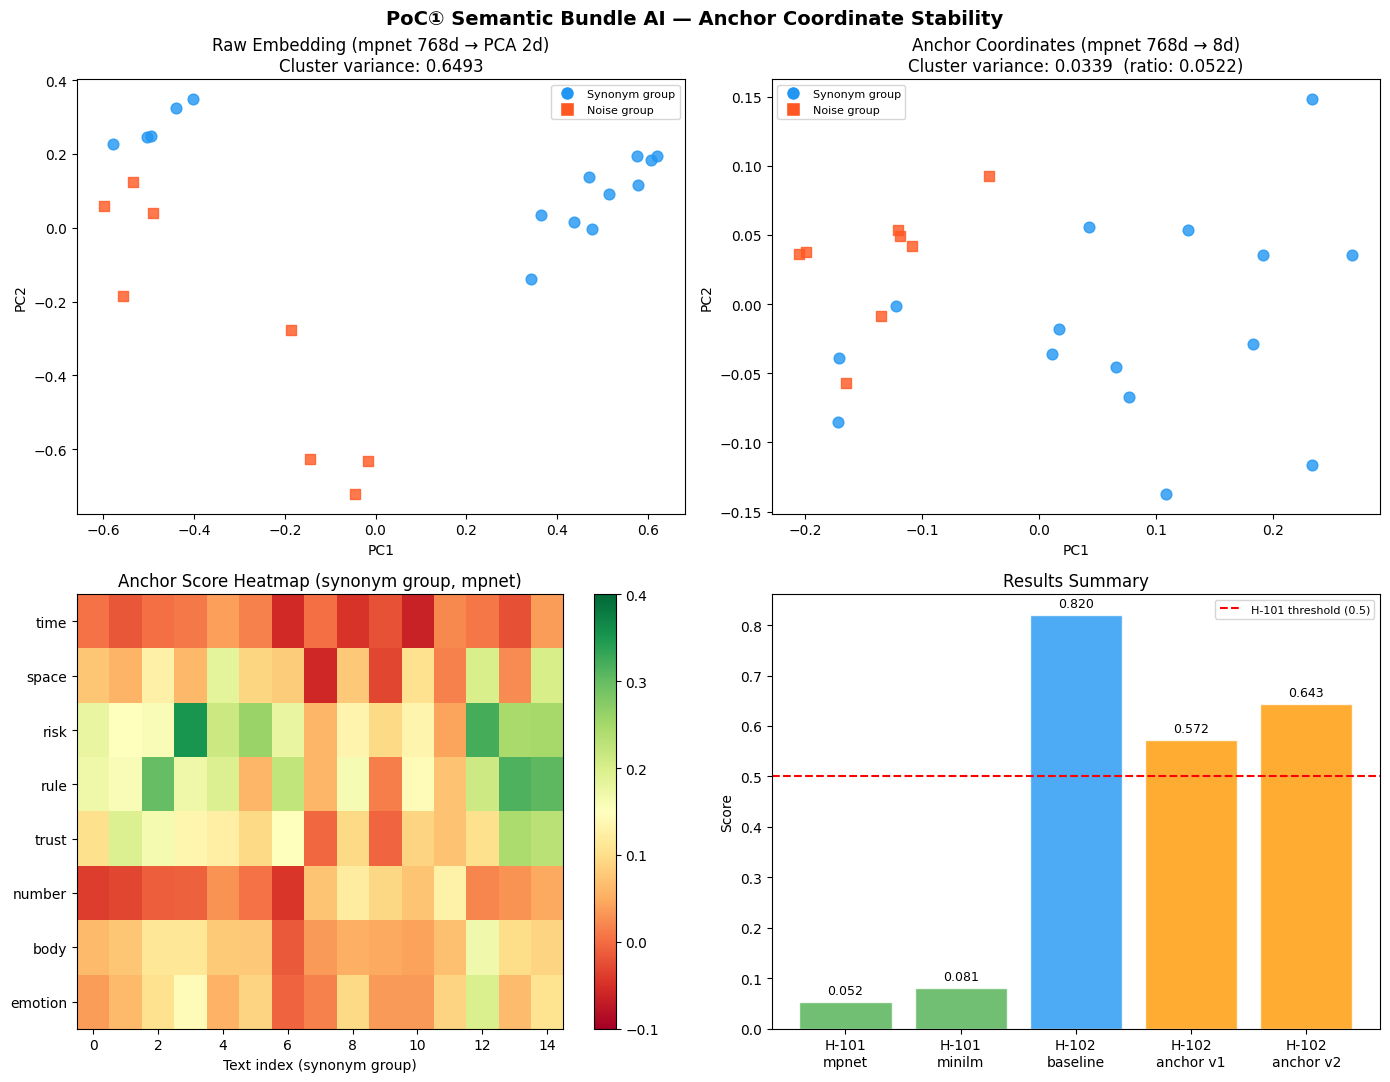

図を保存しました: notebooks/poc_01_results.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("PoC① Semantic Bundle AI — Anchor Coordinate Stability", 
             fontsize=14, fontweight='bold')

colors = ['#2196F3'] * len(SYNONYM_GROUP) + ['#FF5722'] * len(NOISE_GROUP)
markers = ['o'] * len(SYNONYM_GROUP) + ['s'] * len(NOISE_GROUP)

# 左上：生embedding PCA（mpnet）
ax = axes[0, 0]
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_mpnet)
for i, (x, y) in enumerate(emb_2d):
    ax.scatter(x, y, c=colors[i], marker=markers[i], s=60, alpha=0.8)
ax.set_title(f"Raw Embedding (mpnet 768d → PCA 2d)\nCluster variance: {results_h101['mpnet']['var_embedding']:.4f}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# 右上：アンカー座標 PCA（mpnet）
ax = axes[0, 1]
pca2 = PCA(n_components=2)
anc_2d = pca2.fit_transform(anc_mpnet)
for i, (x, y) in enumerate(anc_2d):
    ax.scatter(x, y, c=colors[i], marker=markers[i], s=60, alpha=0.8)
ax.set_title(f"Anchor Coordinates (mpnet 768d → 8d)\nCluster variance: {results_h101['mpnet']['var_anchor']:.4f}  (ratio: {results_h101['mpnet']['ratio']:.4f})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")

# 左下：アンカーごとのスコア分布（ヒートマップ）
ax = axes[1, 0]
anchor_names = list(anchors_mpnet.keys())
heatmap_data = anc_mpnet[syn_idx]
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='RdYlGn', vmin=-0.1, vmax=0.4)
ax.set_yticks(range(len(anchor_names)))
ax.set_yticklabels(anchor_names)
ax.set_xlabel("Text index (synonym group)")
ax.set_title("Anchor Score Heatmap (synonym group, mpnet)")
plt.colorbar(im, ax=ax)

# 右下：結果サマリーバーチャート
ax = axes[1, 1]
metrics = ['H-101\nmpnet', 'H-101\nminilm', 'H-102\nbaseline', 'H-102\nanchor v1', 'H-102\nanchor v2']
values  = [
    results_h101['mpnet']['ratio'],
    results_h101['minilm']['ratio'],
    baseline,
    anchor_consistency,
    anchor_v2,
]
bar_colors = ['#4CAF50','#4CAF50','#2196F3','#FF9800','#FF9800']
bars = ax.bar(metrics, values, color=bar_colors, alpha=0.8, edgecolor='white')
ax.axhline(y=0.5, color='red', linestyle='--', linewidth=1.5, label='H-101 threshold (0.5)')
ax.set_title("Results Summary")
ax.set_ylabel("Score")
ax.legend(fontsize=8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Synonym group'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF5722', markersize=10, label='Noise group'),
]
axes[0, 0].legend(handles=legend_elements, fontsize=8)
axes[0, 1].legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.savefig("../notebooks/poc_01_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("図を保存しました: notebooks/poc_01_results.png")